## Сессия 8 - Работа с Временными рядами. (Анализ динамики основных метрик)

Подготовим данные


In [70]:
import pandas as pd 

df_data = pd.read_csv('data_from_notes/full_data.csv', sep = ';')


cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date', 'review_creation_date', 'review_answer_timestamp']
for col in cols:
    df_data[col] = pd.to_datetime(df_data[col], format = 'mixed')

# Создадим колонку дней доставки, для дальнейшей работы
df_data['delivery_days'] = (df_data['order_delivered_customer_date'] - df_data['order_purchase_timestamp']).dt.days.astype('float32')

# Удалим технические флаги, которые не несут в себе полезной информации
df_data.drop(columns = ['is_delivered', 'confirm', 'conf_&_paid'], inplace = True)

# Создадим флаг, который поможет оставить только те заказы и строки, по которым доставка была действительно произведена, что соответствует цели исследования
df_data['delivered'] = df_data['delivery_days'].notna()

# Оставим только те заказы, доставка которых была произведена и посчитана ранее
df_data = df_data[df_data['delivered']]
df_data = df_data.drop(columns = ['delivered'])

# Отфильтруем данные по дате, так как начальные и конечные месяцы датафрейма имеют неполные данные о месяцах
start_date = '2017-01-01'
end_date = '2018-08-31'

date_mask = (df_data['order_purchase_timestamp'] >= start_date) & (df_data['order_purchase_timestamp'] <= end_date)
data = df_data[date_mask].copy()
# Посмотрим на полученный датафрейм кратко
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 89808 entries, 0 to 92036
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       89808 non-null  object        
 1   customer_id                    89808 non-null  object        
 2   order_status                   89808 non-null  object        
 3   order_purchase_timestamp       89808 non-null  datetime64[ns]
 4   order_approved_at              89796 non-null  datetime64[ns]
 5   order_delivered_carrier_date   89807 non-null  datetime64[ns]
 6   order_delivered_customer_date  89808 non-null  datetime64[ns]
 7   order_estimated_delivery_date  89808 non-null  datetime64[ns]
 8   customer_unique_id             89808 non-null  object        
 9   customer_zip_code_prefix       89808 non-null  int64         
 10  customer_city                  89808 non-null  object        
 11  customer_state      

Далее, подготовим данные под анализ временных рядов

In [71]:
# Создадим новый датафрейм только с нужными полями, так как в исходном датафрейме много лишних полей
clean_data = data[['order_id', 'customer_id', 'customer_unique_id', 'order_purchase_timestamp', 'delivery_days', 'product_category_name', 'payment_value', 'price']].copy()
clean_data = clean_data.rename(columns = {'order_purchase_timestamp': 'order_data'})
full_payment_df = clean_data.groupby(['order_id', 'customer_id', 'product_category_name', 'delivery_days', 'order_data', 'price'])['payment_value'].sum().reset_index()
full_payment_df.set_index('order_data', inplace = True)
full_payment_df.sort_index(inplace = True)

# Посмотрим на часть данных
full_payment_df.head(10)

,order_id,customer_id,product_category_name,delivery_days,price,payment_value
order_data,,,,,,
2017-01-05 11:56:06,ec7a019261fce44180373d45b442d78f,c24fc5f9a446b4d8262041b9c64de772,fashion_bolsas_e_acessorios,6.0,10.9,19.62
2017-01-05 12:01:20,b95a0a8bd30aece4e94e81f0591249d8,ff3c6d35b4927c9b965aa6a68dcf56e4,automotivo,12.0,10.9,19.62
2017-01-05 12:09:08,7a18a504c1a4b32d883e68de2e1a7db0,e6bee29442c761ff0dfb9a4414922a5c,pet_shop,11.0,7.9,16.62
2017-01-05 12:11:23,6acecf438369055d9243e121045cca74,42d857e22f61f10476f0cda1aacc018a,pet_shop,12.0,9.9,18.62
2017-01-05 13:01:48,40599d3d28b75746952ded75566637b9,efdf4a7c78d7c364046efb69035d1d4f,pet_shop,11.0,11.9,20.62
2017-01-05 13:29:03,ce86fa5a5108884726a2244bcae51ae6,8fa33a3159dfc303b8aeccf859b9bee5,fashion_bolsas_e_acessorios,11.0,10.9,19.62
2017-01-05 13:31:22,7004296aa0256632eaddc171edaf727f,3a7856f2a103364d279de7f72e18b7c4,fashion_bolsas_e_acessorios,11.0,10.9,19.62
2017-01-05 13:33:45,cce1b8a1c5f8b1d224e19628299c8f54,63433f6eb6f0a79cbb24e940d0ab17ad,fashion_bolsas_e_acessorios,12.0,10.9,19.62
2017-01-05 13:34:35,f175d67589e059cbbda956f10f0702e6,a4555d257db29ef5f838cec4101c5208,moveis_quarto,12.0,9.9,18.62


Далее, аггрегируем данные по месяцам

In [72]:
monthly_stats = full_payment_df.resample('ME').agg(
    GMV = ('payment_value', 'sum'),
    count_orders = ('order_id', 'nunique'),
    count_customers = ('customer_id', 'nunique'),
    mean_delivery = ('delivery_days', 'mean'),
    median_delivery = ('delivery_days', 'median'),
    std_delivery = ('delivery_days', 'std'),
    mean_price = ('price', 'mean')
)

monthly_stats.head(10)

,GMV,count_orders,count_customers,mean_delivery,median_delivery,std_delivery,mean_price
order_data,,,,,,,
2017-01-31,139889.41,588,588,11.916805,10.0,9.670732,120.182379
2017-02-28,261025.45,1290,1290,12.436981,10.0,10.108176,134.214317
2017-03-31,380664.17,1952,1952,12.305264,10.0,13.947478,127.379940
2017-04-30,358845.65,1779,1779,14.094847,12.0,10.921969,140.483997
2017-05-31,562199.39,2760,2760,10.656790,9.0,7.750454,128.608765
2017-06-30,460882.16,2476,2476,11.477038,10.0,8.440219,126.263262
2017-07-31,570696.10,3028,3028,10.994875,10.0,7.357749,112.816887
2017-08-31,626645.41,3254,3254,10.600835,9.0,7.149591,121.023049
2017-09-30,809178.37,3250,3250,11.270164,10.0,7.295124,129.739055


Посчитаем метрики, которых не хватает


In [73]:
monthly_stats['AOV'] = monthly_stats['GMV'] / monthly_stats['count_orders']
monthly_stats['ARPU'] = monthly_stats['GMV'] / monthly_stats['count_customers']
monthly_stats['MoM'] = (monthly_stats['GMV'].pct_change() * 100).round(2)
monthly_stats['prev_month'] = monthly_stats['GMV'].shift(1)
monthly_stats['diff_prev_month'] = monthly_stats['GMV'].diff() 

monthly_stats.head(15)

,GMV,count_orders,count_customers,mean_delivery,median_delivery,std_delivery,mean_price,AOV,ARPU,MoM,prev_month,diff_prev_month
order_data,,,,,,,,,,,,
2017-01-31,139889.41,588,588,11.916805,10.0,9.670732,120.182379,237.907160,237.907160,NaN,NaN,NaN
2017-02-28,261025.45,1290,1290,12.436981,10.0,10.108176,134.214317,202.345310,202.345310,86.59,139889.41,121136.04
2017-03-31,380664.17,1952,1952,12.305264,10.0,13.947478,127.379940,195.012382,195.012382,45.83,261025.45,119638.72
2017-04-30,358845.65,1779,1779,14.094847,12.0,10.921969,140.483997,201.712001,201.712001,-5.73,380664.17,-21818.52
2017-05-31,562199.39,2760,2760,10.656790,9.0,7.750454,128.608765,203.695431,203.695431,56.67,358845.65,203353.74
2017-06-30,460882.16,2476,2476,11.477038,10.0,8.440219,126.263262,186.139806,186.139806,-18.02,562199.39,-101317.23
2017-07-31,570696.10,3028,3028,10.994875,10.0,7.357749,112.816887,188.472952,188.472952,23.83,460882.16,109813.94
2017-08-31,626645.41,3254,3254,10.600835,9.0,7.149591,121.023049,192.576955,192.576955,9.80,570696.10,55949.31
2017-09-30,809178.37,3250,3250,11.270164,10.0,7.295124,129.739055,248.977960,248.977960,29.13,626645.41,182532.96


Построим визуализации по полученным данным

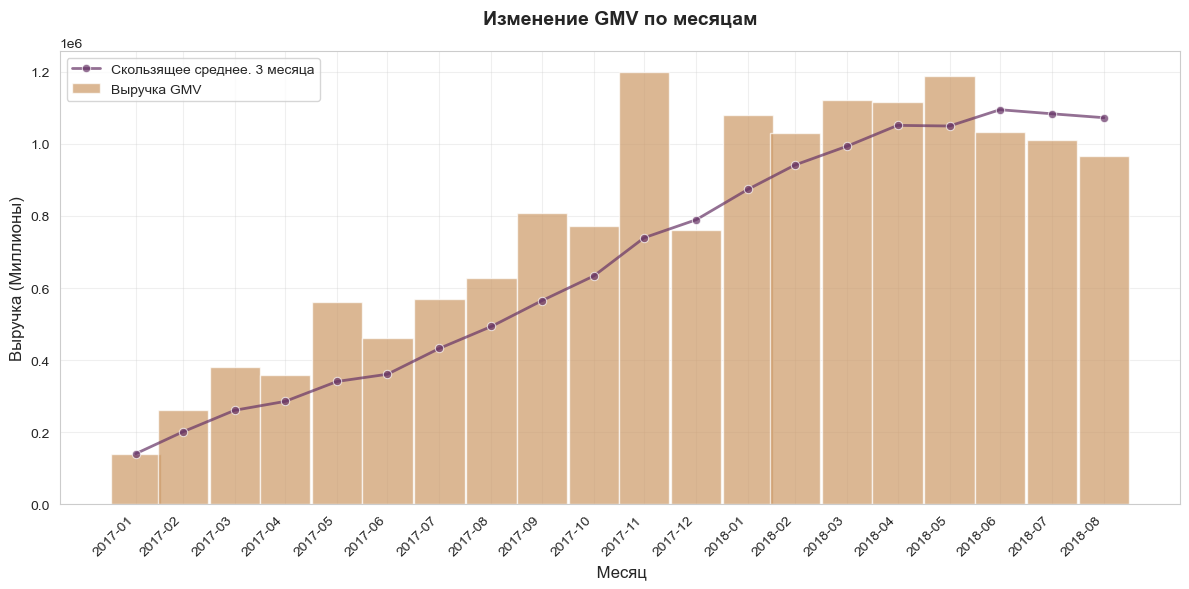

In [74]:
import matplotlib.pyplot as plt
import matplotlib.dates as md
import seaborn as sns
from style import setup_style, decorate

# Построим колонку скользяшего среднего за 3 месяца
monthly_stats['ma3'] = monthly_stats['GMV'].rolling(window = 6, min_periods = 1).mean()
# Построим столбачтую диаграмму для GMV с линией скользящего среднего.
setup_style()
fig, ax = plt.subplots(figsize = (12, 6))

ax.bar(monthly_stats.index, monthly_stats['GMV'], color = '#CC9966', alpha = 0.7, width = 30, label = 'Выручка GMV')
sns.lineplot(data = monthly_stats, x = monthly_stats.index, y = 'ma3', alpha = 0.7, linewidth = 2, color = "#663366", marker = 'o', label = 'Скользящее среднее. 3 месяца', ax = ax)
decorate(ax, 'Изменение GMV по месяцам', ' Месяц', 'Выручка (Миллионы)')
ax.set_xticks(monthly_stats.index)
ax.xaxis.set_major_formatter(md.DateFormatter('%Y-%m'))
plt.xticks(rotation = 45, ha = 'right')
plt.legend()
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Выручка (Миллионы)')

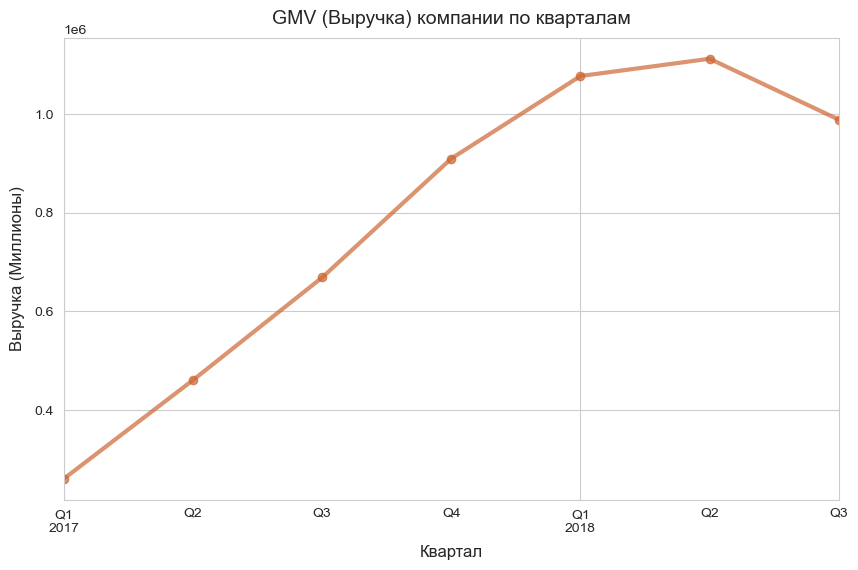

In [75]:
quartal_gmv = monthly_stats['GMV'].resample('QE').mean()
quartal_gmv.plot(kind = 'line', linewidth = 3, alpha = 0.7, marker = 'o', color = "#CC6633")
plt.title('GMV (Выручка) компании по кварталам', pad = 10)
plt.xlabel('Квартал', labelpad = 7)
plt.ylabel('Выручка (Миллионы)', labelpad = 7)

Также, пока мы анализируем выручку, создадим график MOM Роста

c:\Users\User\Analytics-Training\sprint2_olist\work_with_pandas\style.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


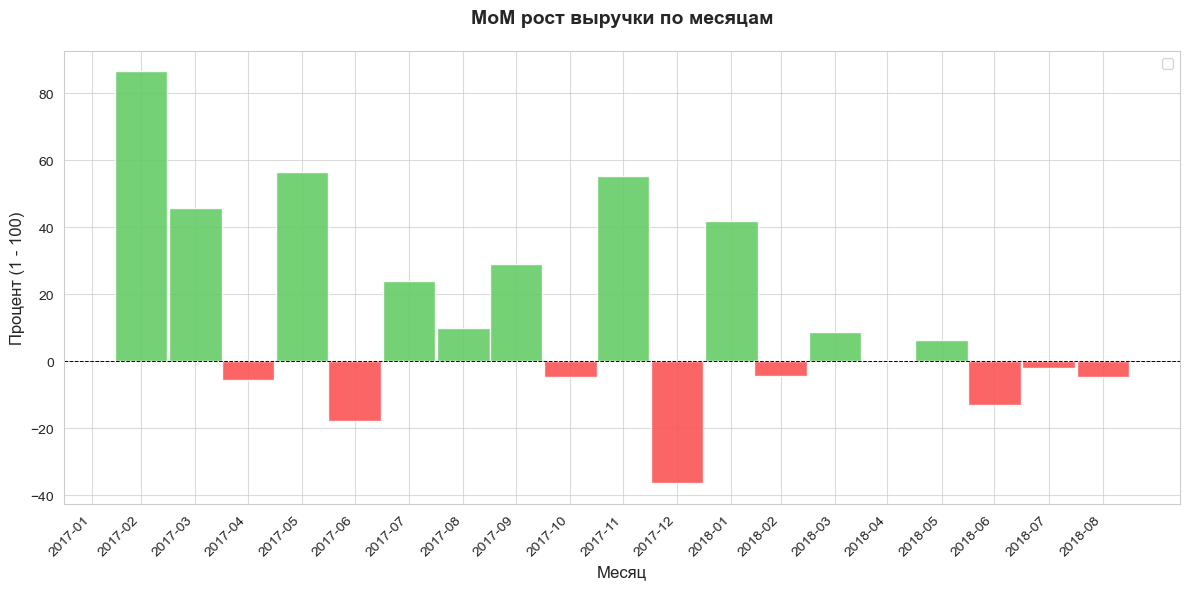

In [76]:
fig, ax = plt.subplots(figsize = (12, 6))

colour = ["#66CC66" if x > 0 else "#FB5454" for x in monthly_stats['MoM']]
ax.bar(monthly_stats.index, monthly_stats['MoM'], color = colour, width = 30, alpha = 0.9)
ax.axhline(0, color = 'black', linewidth = 0.7, linestyle = '--')
decorate(ax, 'MoM рост выручки по месяцам', 'Месяц', 'Процент (1 - 100)')
ax.set_xticks(monthly_stats.index)
ax.xaxis.set_major_formatter(md.DateFormatter('%Y-%m'))
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.grid(True, alpha = 0.7)


**Вывод по динамике выручки:**
- Анализ временного ряда подтверждает общую положительную динамику компании на исследуемом отрезке, однако в последние месяцы наблюдается стагнация и нисходящий тренд.

- Эффект высокой сезонности: Пик выручки в ноябре 2017 года обусловлен подготовкой к праздничному сезону и проведением крупных промо-акций (прим. Черная пятница).

- Декабрьская коррекция: Последовавшее снижение в декабре 2017 года выглядит закономерным откатом после аномального всплеска активности в ноябре (удовлетворение отложенного спроса).

- Динамика 2018 года: Начало года характеризуется умеренным ростом, который может быть связан с реализацией отложенных заказов после праздников. Однако в следующие месяцы выручкка компании редко демонстрирует рост и принимает тренд на снижение (Особенно это видно по динамике второго квартала 2018 года).

- Проблемы с масштабированием: Учитывая выявленные ранее проблемы с удержанием клиентов (Retention), можно сделать вывод, что текущий спад выручки связан с неспособностью компании удерживать базу на фоне замедления притока новых пользователей. Без работы над лояльностью текущий тренд на снижение может усилиться.

**Построим комбинированный график AOV**

(array([17197., 17225., 17256., 17286., 17317., 17347., 17378., 17409.,
        17439., 17470., 17500., 17531., 17562., 17590., 17621., 17651.,
        17682., 17712., 17743., 17774.]),
 [Text(17197.0, 0, '2017-01'),
  Text(17225.0, 0, '2017-02'),
  Text(17256.0, 0, '2017-03'),
  Text(17286.0, 0, '2017-04'),
  Text(17317.0, 0, '2017-05'),
  Text(17347.0, 0, '2017-06'),
  Text(17378.0, 0, '2017-07'),
  Text(17409.0, 0, '2017-08'),
  Text(17439.0, 0, '2017-09'),
  Text(17470.0, 0, '2017-10'),
  Text(17500.0, 0, '2017-11'),
  Text(17531.0, 0, '2017-12'),
  Text(17562.0, 0, '2018-01'),
  Text(17590.0, 0, '2018-02'),
  Text(17621.0, 0, '2018-03'),
  Text(17651.0, 0, '2018-04'),
  Text(17682.0, 0, '2018-05'),
  Text(17712.0, 0, '2018-06'),
  Text(17743.0, 0, '2018-07'),
  Text(17774.0, 0, '2018-08')])

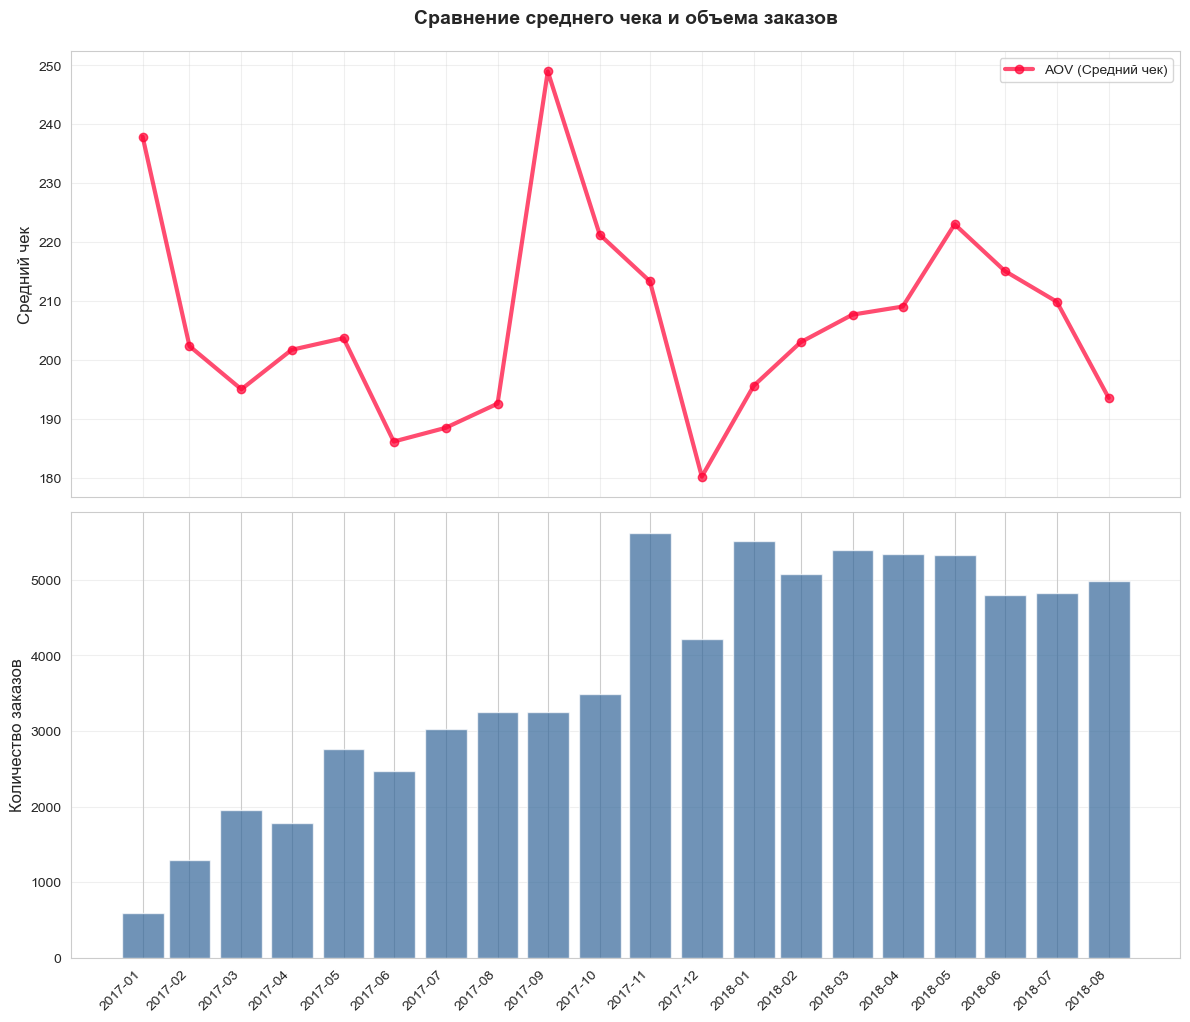

In [77]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(monthly_stats.index, monthly_stats['AOV'], color = "#FF0033", marker = 'o', linewidth = 3, alpha = 0.7, label = 'AOV (Cредний чек)')
decorate(ax1, 'Сравнение среднего чека и объема заказов', '', 'Средний чек')
ax1.grid(True, axis = 'y', alpha = 0.3)

ax2.bar(monthly_stats.index, monthly_stats['count_orders'], color = "#336699", alpha = 0.7, width = 25, label = 'Количество клиентов')
ax2.set_ylabel('Количество заказов')
ax2.grid(True, axis = 'y', alpha = 0.3)

ax2.set_xticks(monthly_stats.index)
ax2.xaxis.set_major_formatter(md.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.xticks(rotation = 45, ha = 'right')



Text(0, 0.5, 'AOV (Средний чек)')

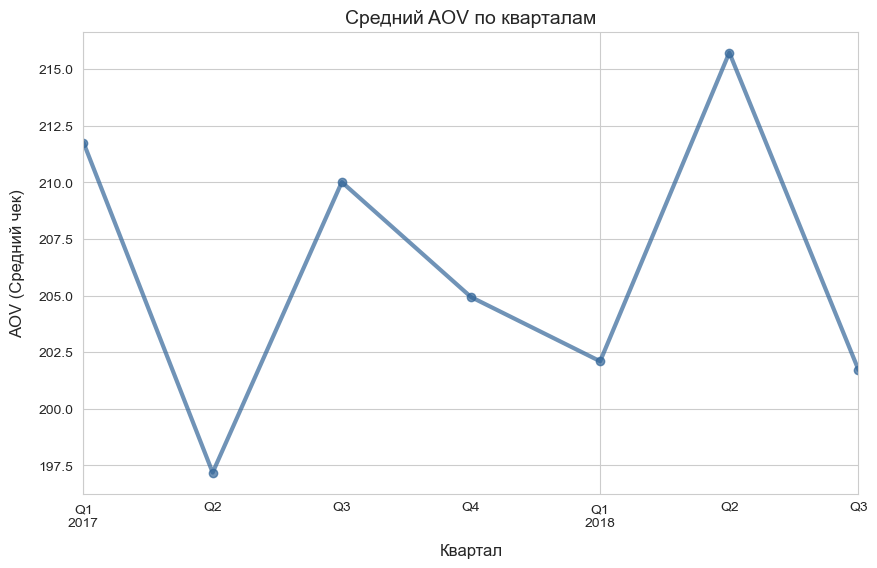

In [78]:
quartal_aov = monthly_stats['AOV'].resample('QE').mean()
quartal_aov.plot(kind = 'line', linewidth = 3, alpha = 0.7, color = '#336699', marker = 'o', title = 'Средний AOV по кварталам')
plt.xlabel('Квартал', labelpad = 10)
plt.ylabel('AOV (Средний чек)', labelpad = 10)


Выше мы отобразили две диаграммы, которые отражают динамику AOV. Первая диаграмма является комплексной визуализацией, где совмещается линейный график динамики AOV по месяцам и столбчатая диаграмма, отражающая количество клиентов, второй график является обычным линейным графиком, отражающим квартильную динамику AOV.  всего периода

**Выводы по графикам:**
- Этап 1 (январь — август 2017): Период формирования базы. При стабильном росте количества заказов наблюдаются резкие колебания среднего чека (AOV), что может указывать на поиск оптимальной ценовой модели.
- Этап 2 (сентябрь — декабрь 2017): В сентябре зафиксирован аномальный пик AOV (~248). Ноябрь стал рекордным по числу заказов (вероятное влияние сезонных распродаж), после чего в декабре последовал резкий спад как чека, так и объема заказов, что характерно для коррекции после крупных акций.
- Этап 3 (2018 год): В первом квартале наблюдался качественный рост — количество заказов и чек росли параллельно. Однако во втором квартале динамика замедлилась: снижение AOV вместе с замедлением темпов роста заказов указывает на исчерпание текущего ресурса привлечения.


(array([17197., 17225., 17256., 17286., 17317., 17347., 17378., 17409.,
        17439., 17470., 17500., 17531., 17562., 17590., 17621., 17651.,
        17682., 17712., 17743., 17774.]),
 [Text(17197.0, 0, '2017-01'),
  Text(17225.0, 0, '2017-02'),
  Text(17256.0, 0, '2017-03'),
  Text(17286.0, 0, '2017-04'),
  Text(17317.0, 0, '2017-05'),
  Text(17347.0, 0, '2017-06'),
  Text(17378.0, 0, '2017-07'),
  Text(17409.0, 0, '2017-08'),
  Text(17439.0, 0, '2017-09'),
  Text(17470.0, 0, '2017-10'),
  Text(17500.0, 0, '2017-11'),
  Text(17531.0, 0, '2017-12'),
  Text(17562.0, 0, '2018-01'),
  Text(17590.0, 0, '2018-02'),
  Text(17621.0, 0, '2018-03'),
  Text(17651.0, 0, '2018-04'),
  Text(17682.0, 0, '2018-05'),
  Text(17712.0, 0, '2018-06'),
  Text(17743.0, 0, '2018-07'),
  Text(17774.0, 0, '2018-08')])

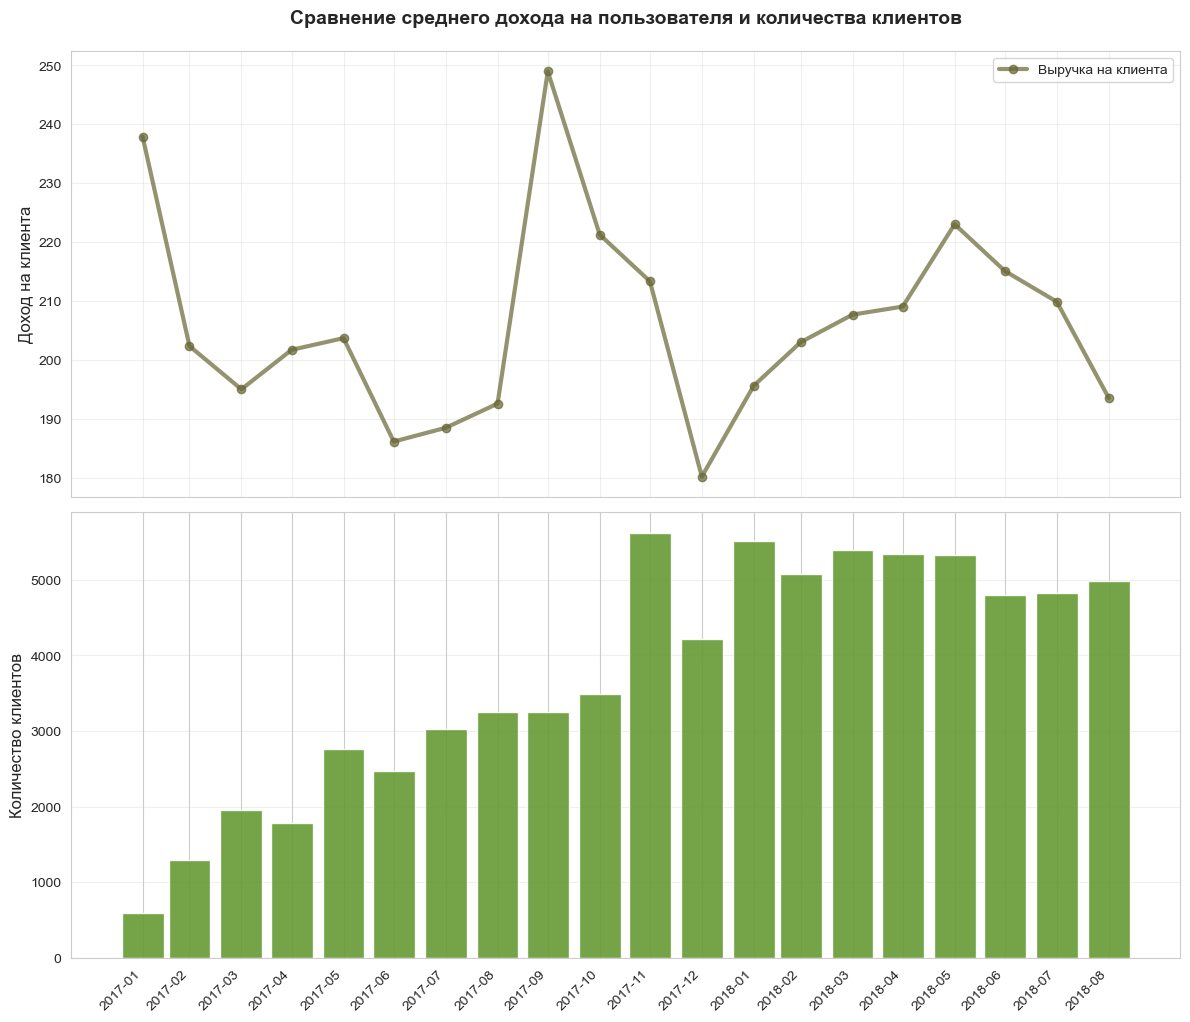

In [79]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(monthly_stats.index, monthly_stats['ARPU'], color = "#666633", marker = 'o', linewidth = 3, alpha = 0.7, label = 'Выручка на клиента')
decorate(ax1, 'Сравнение среднего дохода на пользователя и количества клиентов', '', 'Доход на клиента')
ax1.grid(True, alpha = 0.3)

ax2.bar(monthly_stats.index, monthly_stats['count_customers'], color = "#669933", alpha = 0.9, width = 25, label = 'Количество клиентов')
ax2.set_ylabel('Количество клиентов')
ax2.grid(True, axis = 'y', alpha = 0.3)

ax2.set_xticks(monthly_stats.index)
ax2.xaxis.set_major_formatter(md.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.xticks(rotation = 45, ha = 'right')

Text(0, 0.5, 'ARPU (Доход на клиента)')

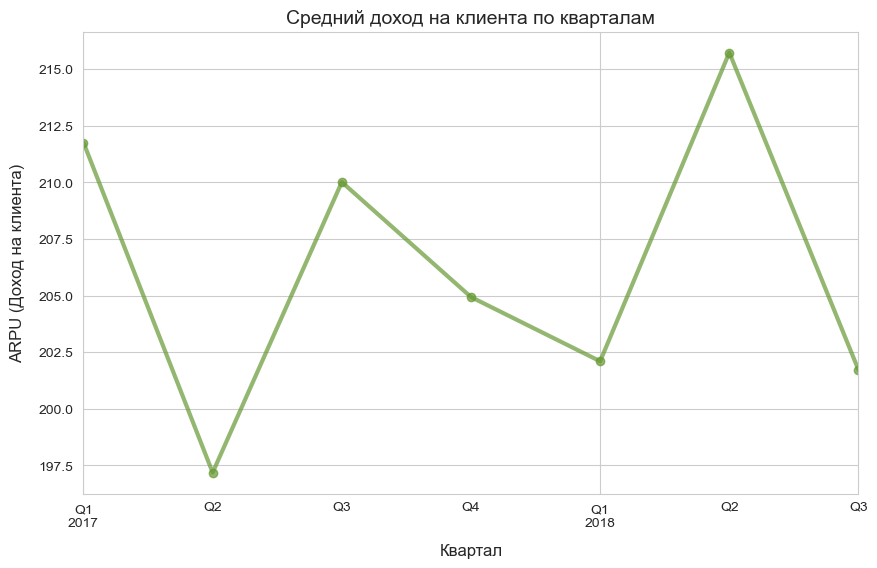

In [80]:
quartal_arpu = monthly_stats['ARPU'].resample('QE').mean()
quartal_aov.plot(kind = 'line', linewidth = 3, alpha = 0.7, color = "#669933", marker = 'o', title = 'Средний доход на клиента по кварталам')
plt.xlabel('Квартал', labelpad = 10)
plt.ylabel('ARPU (Доход на клиента)', labelpad = 10)


**Выводы по динамике ARPU и клиентской базы:**
- Фаза 1 (январь — август 2017): На фоне стабильного роста числа активных клиентов (с <1000 до >3000) наблюдалась высокая волатильность ARPU. Это указывает на активное привлечение новых клиентов и проведения активной маркетинговой компании по привлечению
- Фаза 2 (сентябрь — декабрь 2017): В сентябре был достигнут максимум дохода на одного клиента (248). Ноябрь стал пиковым по объему базы (>5000 клиентов), однако декабрь показал резкое снижение обеих метрик: доход на клиента упал до минимума, что может говорить о коррекции после проведения масштабных акций, таких как "Черная пятница"
- Фаза 3 (2018 год): В начале года показатели восстановились, но с мая 2018 года наметился нисходящий тренд: количество клиентов стабилизировалось, а ARPU начал плавно снижаться. Это говорит о том, что компании не удается удержать клиентскую базу и требуются новые стратегии, в первую очередь по удержанию клиентской базы и повышению ценности каждого отдельного пользователя

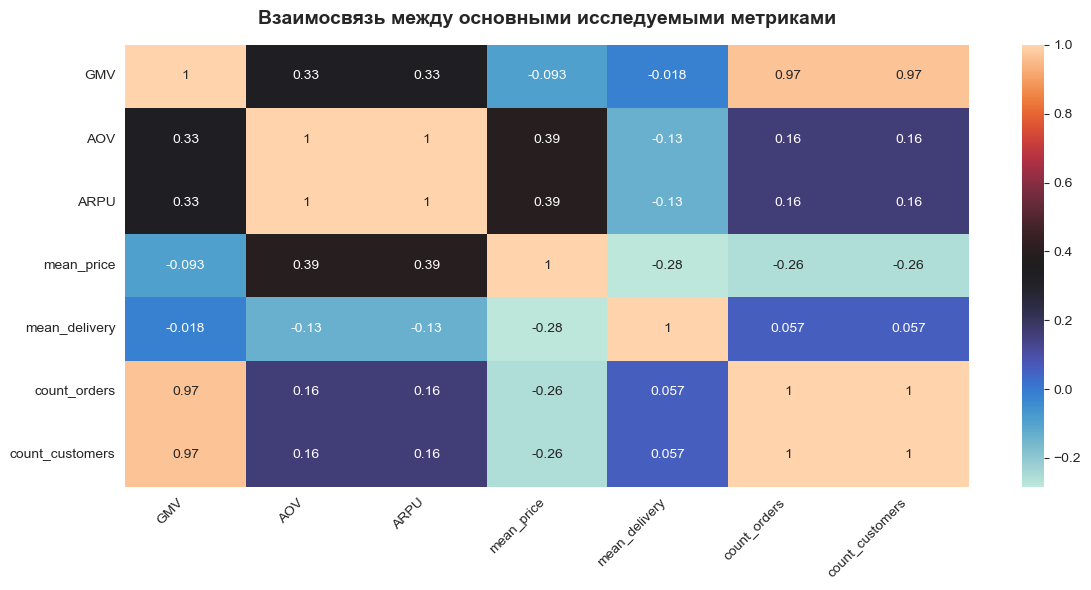

In [110]:
import numpy as np
cols_need = ['GMV', 'AOV', 'ARPU', 'mean_price', 'mean_delivery', 'count_orders', 'count_customers']
corr_data = monthly_stats[cols_need].corr(method = 'spearman')

fig, ax = plt.subplots(figsize = (12, 6))
#mask = np.triu(np.ones_like(corr_data, dtype = bool))
sns.heatmap(data = corr_data, cmap = 'icefire', annot = True, ax = ax)
plt.title('Взаимосвязь между основными исследуемыми метриками', fontweight = 'bold', pad = 15)
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()



**Корреляционный анализ подтверждает, что динамика ключевых метрик (AOV, ARPU) весьма сильно связано с ростом цен на самой площадке, а не ростом потребительской активности:**
**Фактор цены:** Связь между средней ценой товара и средним чеком составляет 0.39 (по Спирмену). Это умеренная, но значимая корреляция, которая подтверждает: в рассматриваемые периоды на рост AOV и ARPU сильно влияла ценовая политика площадки. Мы имеем связь при которой при повышении цены средний чек и выручка на пользователя также стремилось вверх.
**Драйвер выручки:** Основным фактором роста GMV остается экстенсивное расширение базы ( положительная корреляция с count_orders 0.97). Вклад среднего чека в общий оборот значительно ниже и составляет 0.33.
**Идентичность метрик:** Коэффициент корреляции 1.0 между AOV и ARPU, а также между count_orders и count_customers математически доказывает отсутствие повторных продаж внутри месяца, что говорит об огромной проблеме с удержанием и поддержанием ценности уже имеющейся клиентской базы. Корреляция 1.0 говорит о том, что люди, в большинстве своем уходят и никогда не возвращаются. Если данная ситуация не будет исправлена, то компания может иметь большие проблемы с лояльностью и как следствие с продажами на торговой площадке в будущем


##### Итоговый вывод:
Анализ данных за 2017–2018 гг. показывает значительный рост операционных показателей: количество заказов увеличилось почти в 10 раз. Однако этот рост носит преимущественно экстенсивный характер и обеспечивается постоянным притоком новых пользователей. Ключевой особенностью текущей модели является отсутствие повторных продаж внутри месяца — на это указывает идентичность графиков AOV и ARPU, а также прямая корреляция между ними. Фактически площадка работает в режиме разовых транзакций, где клиент не возвращается за повторной покупкой в краткосрочном периоде.
При этом положительная динамика среднего чека (AOV) в 2018 году во многом объясняется не качественным изменением потребительского поведения, а ростом цен на товары (корреляция с mean_price составляет 0.39). Опыт проведения крупных акций в конце 2017 года также подтверждает, что резкое увеличение объема заказов за счет скидок приводит к закономерному падению среднего чека и последующему оттоку части аудитории в следующем месяце.
В качестве основного вывода можно отметить, что проект демонстрирует высокую способность к масштабированию базы, но имеет низкие показатели удержания. Главным вектором развития должно стать внедрение инструментов Retention-маркетинга. Это позволит увеличить частоту покупок и обеспечит рост ARPU за счет формирования лояльной аудитории, а не только за счет инфляции цен и привлечения нового трафика.
